<a href="https://colab.research.google.com/github/dayfuti546/Yolov7_ObjectDetection/blob/dayfuti546-patch-1/KoBERT_%EA%B8%B0%EB%B0%98_%EB%AC%B8%EB%A7%A5_%EC%9D%B8%EC%8B%9D_%ED%94%BC%EC%8B%B1_%EB%B6%84%EB%A5%98_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 7.1 MB/s eta 0:00:00


🎯 현재 연산 디바이스: cuda
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Complete
--- [1/2] 정상 데이터 OCR 추출 시작 ---


100%|██████████| 170/170 [05:11<00:00,  1.83s/it]



--- [2/2] 피싱 데이터 OCR 추출 시작 ---


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔎 테스트 데이터셋 검증 중...



=== 📝 KoBERT 상세 평가지표 ===
              precision    recall  f1-score   support

   Normal(0)       0.94      0.94      0.94        34
 Phishing(1)       0.93      0.93      0.93        27

    accuracy                           0.93        61
   macro avg       0.93      0.93      0.93        61
weighted avg       0.93      0.93      0.93        61



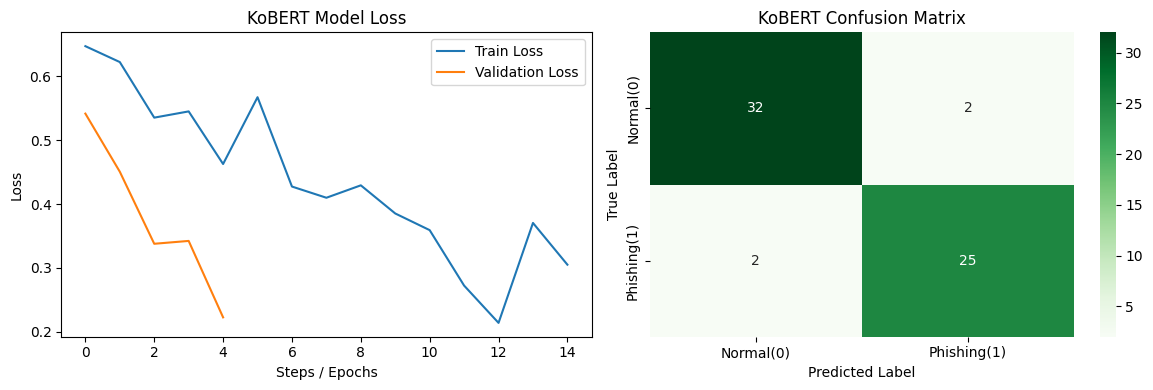

In [2]:
# 1. 필수 패키지 설치 (버전 락 방지를 위한 규격화)
!pip install -q easyocr transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

# 2. 업로드해두신 dataset.zip.zip 압축 해제 (여기가 상자 여는 단계입니다!)
!unzip -q -o /content/dataset.zip.zip -d /content/

import os
import random
import easyocr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# 시드 고정 및 디바이스 설정
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🎯 현재 연산 디바이스: {device}")

# 3. 압축이 풀린 이미지 폴더에서 다시 텍스트 긁어모으기
reader = easyocr.Reader(['ko', 'en'], gpu=True)
correct_folder = '/content/correct'
phishing_folder = '/content/phishing'

data_list = []

print("\n--- [1/2] 정상 데이터 OCR 추출 시작 ---")
if os.path.exists(correct_folder):
    for filename in tqdm(os.listdir(correct_folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(correct_folder, filename)
            try:
                result = reader.readtext(image_path, detail=0)
                data_list.append({'text': " ".join(result), 'label': 0})
            except:
                pass
else:
    print("❌ correct 폴더를 찾을 수 없습니다. 압축파일 내부 구조를 확인해 주세요.")

print("\n--- [2/2] 피싱 데이터 OCR 추출 시작 ---")
if os.path.exists(phishing_folder):
    for filename in tqdm(os.listdir(phishing_folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(phishing_folder, filename)
            try:
                result = reader.readtext(image_path, detail=0)
                data_list.append({'text': " ".join(result), 'label': 1})
            except:
                pass
else:
    print("❌ phishing 폴더를 찾을 수 없습니다. 압축파일 내부 구조를 확인해 주세요.")

if not data_list:
    raise ValueError("❌ 추출된 데이터가 없습니다. dataset.zip.zip 파일이 파일 창에 완전히 업로드 완료되었는지 확인해 주세요.")

# 4. 판다스 데이터프레임으로 변환하고, 다음에 또 날아가는 걸 막기 위해 새 CSV 파일로 강제 백업 저장!
df = pd.DataFrame(data_list)
df['text'] = df['text'].fillna('')
df.to_csv('/content/phishing_dataset.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 데이터 정제 및 'phishing_dataset.csv' 새로 백업 완료! (총 샘플 수: {len(df)}개)")

# 5. 데이터 분리 및 KoBERT 토큰화
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=seed, stratify=df['label']
)

model_name = "skt/kobert-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 6. KoBERT 모델 정의 및 컴파일
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

# 트레이너 하이퍼파라미터 세팅 (최신 규격)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n🚀 KoBERT 기반 피싱 분류 Fine-tuning 시작...")
trainer.train()

print("\n🔎 테스트 데이터셋 검증 중...")
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = test_df['label'].values

print("\n=== 📝 KoBERT 상세 평가지표 ===")
print(classification_report(y_test, y_pred, target_names=['Normal(0)', 'Phishing(1)']))

# 7. 시각화 그래프 출력
history = trainer.state.log_history
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
if eval_loss:
    plt.plot(eval_loss, label='Validation Loss')
plt.title('KoBERT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Steps / Epochs')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal(0)', 'Phishing(1)'],
            yticklabels=['Normal(0)', 'Phishing(1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('KoBERT Confusion Matrix')

plt.tight_layout()
plt.show()

# 8. 최종 실시간 사진 판별 추론 함수
def predict_phishing_danger(image_path):
    result = reader.readtext(image_path, detail=0)
    extracted_text = " ".join(result)

    if not extracted_text.strip():
        print("\n🍏 [안전] 이미지에서 추출된 텍스트가 없어 안전한 페이지로 판단됩니다.")
        return

    inputs = tokenizer(extracted_text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    phishing_prob = probabilities[1]
    pred_class = int(phishing_prob > 0.5)

    print("\n" + "="*20 + " 🚨 실시간 웹사이트 위험도 스캔 🚨 " + "="*20)
    print(f"🔎 [이미지 스캔 문장]: {extracted_text}")
    print(f"📊 #-- Y_predicted_probability --# : {phishing_prob:.6f}")
    print(f"📊 #-- Y_predicted_classes --#     : {pred_class}")
    print("-"*65)

    if pred_class == 1:
        print(f"🚨 [경고] 피싱 위험도가 {phishing_prob*100:.2f}%로 매우 높습니다! 접속을 차단합니다.")
    else:
        print(f"🍏 [안전] 피싱 위험도가 {phishing_prob*100:.2f}%로 안전한 정상 사이트입니다.")
    print("="*66)